# Adiantando a saida

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carrega e prepara os dados
data = pd.read_csv("../DataSpline.csv")
data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)

data["theta"] = data["theta(Wd,We)"]
data["theta(Wd,We)"] = data["theta(Wd,We)"].shift(1)

data = data.iloc[1:]

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)", "theta"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Paletas manuais para preditores e alvos
    predictor_colors = plt.cm.tab10.colors
    target_colors = plt.cm.Set2.colors

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot preditores no eixo esquerdo
    for i, preds in enumerate(PREDICTORS):
        ax1.plot(df.index, df[preds], marker="o", label=preds,
                 color=predictor_colors[i % len(predictor_colors)],
                 linewidth=2)

    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")
    ax1.tick_params(axis='y', labelcolor="black")

    # Plot alvos no eixo direito, se ativado
    if PlotOut:
        ax2 = ax1.twinx()
        for i, target in enumerate(TARGET):
            ax2.plot(df.index, df[target], marker="s", linestyle="--", label=target,
                     color=target_colors[i % len(target_colors)],
                     linewidth=2)
        ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")
        ax2.tick_params(axis='y', labelcolor="gray")

    # Legendas separadas
    leg1 = ax1.legend(loc="upper left", title="Preditores")
    ax1.add_artist(leg1)  # Necessário para manter ambas visíveis
    if PlotOut:
        ax2.legend(loc="upper right", title="Alvos")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)
    
    # Layout e exportação
    plt.tight_layout()
    plt.savefig(f"content/figs/{img_name}", format="svg", dpi=600)
    plt.show()



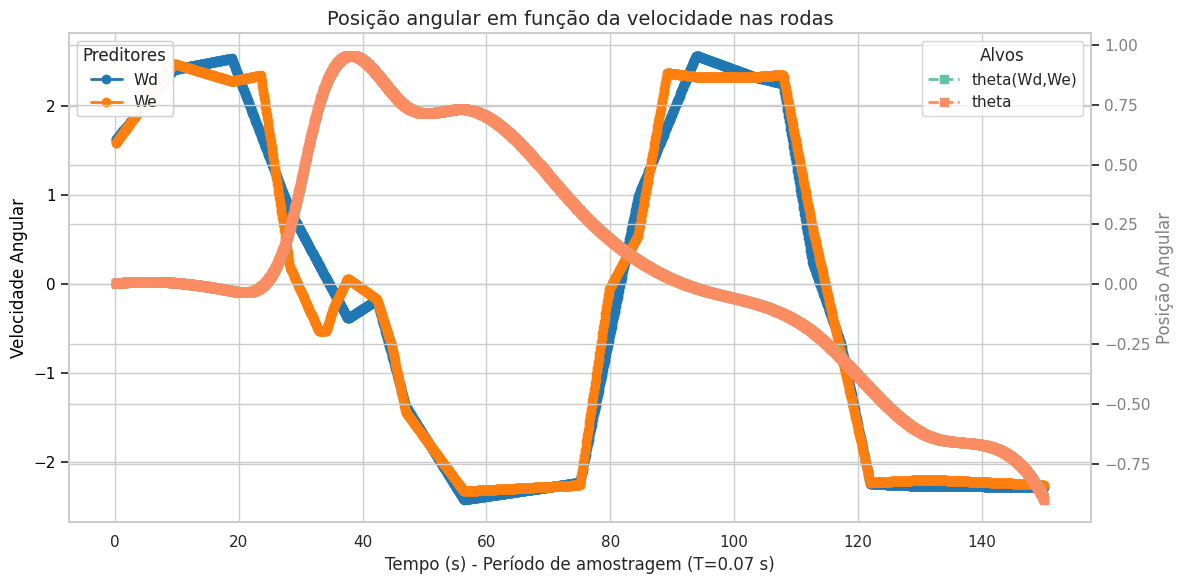

In [37]:
PlotTimeSeries(data)

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykrige.ok3d import OrdinaryKriging3D
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

PREDICTORS = ["Wd", "We", "theta"]
TARGET = "theta(Wd,We)"

VARIOGRAMS = ["gaussian", "spherical", "exponential", "power", "linear", "hole-effect"]

class Kriging3D:
    
    def __init__(self, Dataset):        

        train_data, test_data = train_test_split(Dataset, test_size=0.25, shuffle=False)

        self.train_samples_x = np.array(train_data[PREDICTORS])
        self.train_samples_y = np.array(train_data[TARGET])
        
        self.test_samples_x = np.array(test_data[PREDICTORS])
        self.test_samples_y = np.array(test_data[TARGET])
        
        self.train_time = Dataset.head(np.size(self.train_samples_y)).index
        self.test_time = Dataset.tail(np.size(self.test_samples_y)).index

        self.kriging_model = None

        
    def BuildModel(self, VariogramType):
        self.kriging_model = OrdinaryKriging3D(
            self.train_samples_x[:, 0], 
            self.train_samples_x[:, 1], 
            self.train_samples_x[:, 2], 
            self.train_samples_y, 
            variogram_model=VariogramType
        )
    
    def ComputeMetrics(self):
        self.train_pred = self.kriging_model.execute('points',
                                             self.train_samples_x[:, 0],
                                             self.train_samples_x[:, 1],
                                             self.train_samples_x[:, 2])[0]
        
        self.test_pred = self.kriging_model.execute('points',
                                             self.test_samples_x[:, 0],
                                             self.test_samples_x[:, 1],
                                             self.test_samples_x[:, 2])[0]
        

        return ({
                    'r2_training': r2_score(self.train_samples_y, self.train_pred),
                    'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
                    'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
                    'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

                    'r2_test': r2_score(self.test_samples_y, self.test_pred),
                    'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
                    'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
                    'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
            })
        
    
    def PlotOut(self, variogram):
        # Cores diferentes para cada linha
        colors = plt.cm.tab10.colors  # Paleta com 10 cores distintas

        # Criação da figura com dois subplots lado a lado
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

        # Plot Treinamento
        ax1.plot(self.train_time, self.train_pred, marker="o", linewidth=2,
                label="train_pred", color=colors[0])
        ax1.plot(self.train_time, self.train_samples_y, marker="o", linewidth=2,
                label="train_orig", color=colors[1])
        ax1.set_title("Dados de Treinamento", fontsize=13)
        ax1.set_xlabel("Tempo (s)", fontsize=12)
        ax1.set_ylabel("Velocidade Angular", fontsize=12)
        ax1.legend()
        ax1.grid(True)

        # Plot Teste
        ax2.plot(self.test_time, self.test_pred, marker="o", linewidth=2,
                label="test_pred", color=colors[2])
        ax2.plot(self.test_time, self.test_samples_y, marker="o", linewidth=2,
                label="test_orig", color=colors[3])
        ax2.set_title("Dados de Teste", fontsize=13)
        ax2.set_xlabel("Tempo (s)", fontsize=12)
        ax2.legend()
        ax2.grid(True)

        # Título geral
        fig.suptitle(f"Resultados do modelo Kriging 2D: {variogram}", fontsize=15)

        # Salvando a figura
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajusta espaço para o suptitle
        plt.savefig(f"content/figs/{variogram}.svg", format="svg", dpi=600)

        # Exibe o gráfico
        plt.show()
                    
    
    def EvalModel(self, excel_path):
        self.models = {}
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            for variogram in VARIOGRAMS:
                self.BuildModel(VariogramType=variogram)
                metrics = self.ComputeMetrics()
                self.models[variogram] = self.kriging_model
                
                display(metrics)
                df = pd.DataFrame([metrics])  
                df.to_excel(writer, sheet_name=variogram, index=False)
                self.PlotOut(variogram)

{'r2_training': 1.0,
 'mse_training': 3.657290868125928e-25,
 'mape_training': 3.0321118967059185e-11,
 'rmse_training': 6.047553941988387e-13,
 'r2_test': -0.4372293965030254,
 'mse_test': 0.0436828138753281,
 'mape_test': 0.3120303850721897,
 'rmse_test': 0.20900433936961238}

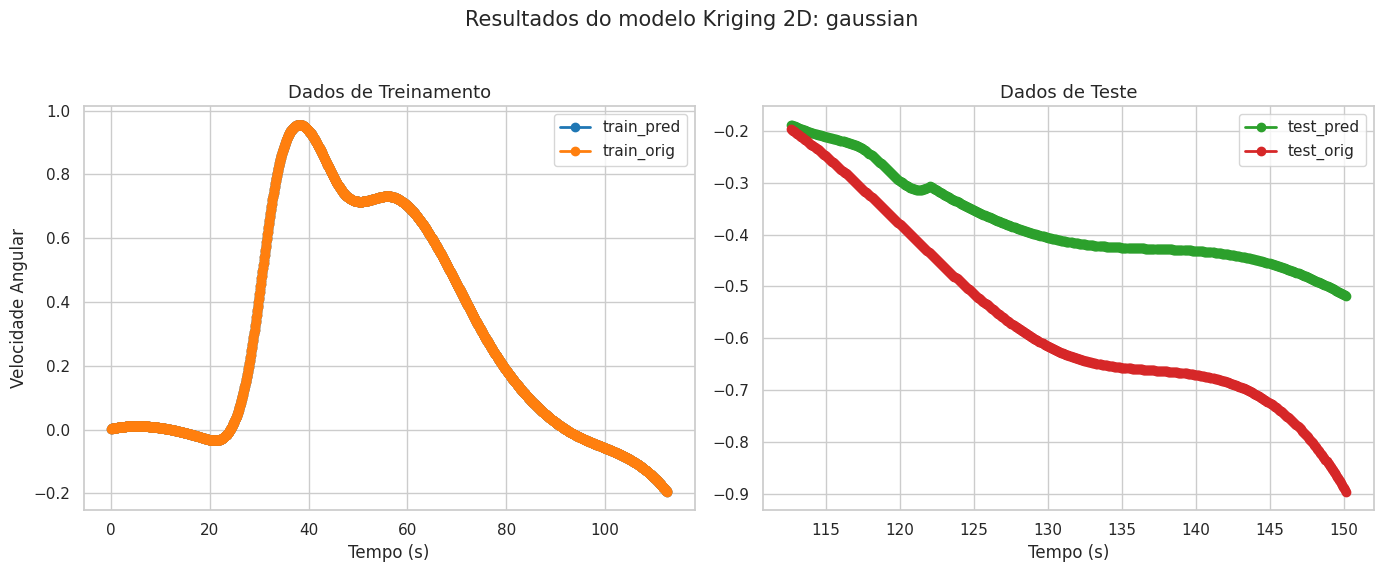

{'r2_training': 1.0,
 'mse_training': 2.8953595233786723e-24,
 'mape_training': 1.073375330840289e-10,
 'rmse_training': 1.7015756002536803e-12,
 'r2_test': -11.628144660065104,
 'mse_test': 0.38381687301869843,
 'mape_test': 1.0104447803596328,
 'rmse_test': 0.6195295578248857}

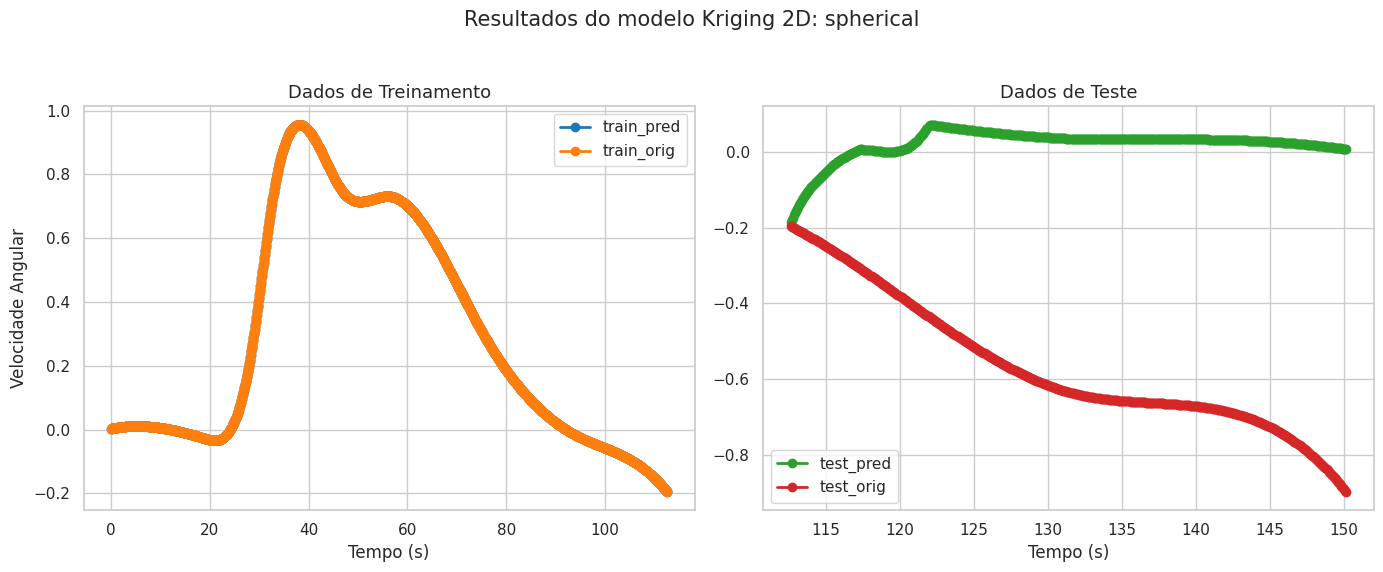

{'r2_training': 1.0,
 'mse_training': 6.104085929604302e-25,
 'mape_training': 8.311773464155246e-11,
 'rmse_training': 7.812864986420987e-13,
 'r2_test': -16.34376352799788,
 'mse_test': 0.5271422891395336,
 'mape_test': 1.2028787058240444,
 'rmse_test': 0.7260456522420154}

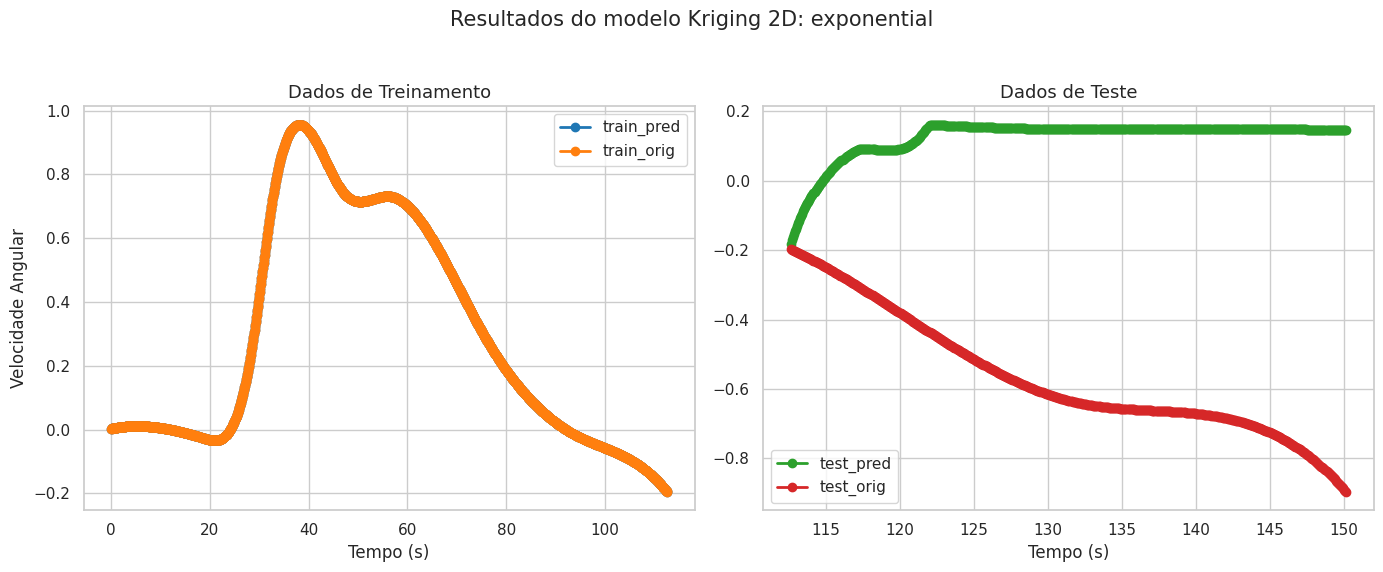

{'r2_training': 1.0,
 'mse_training': 3.589169525381447e-26,
 'mape_training': 1.3259134437931192e-11,
 'rmse_training': 1.8945103656041177e-13,
 'r2_test': -16.31883431917671,
 'mse_test': 0.5263845966016242,
 'mape_test': 1.2102101706873565,
 'rmse_test': 0.7255236706005009}

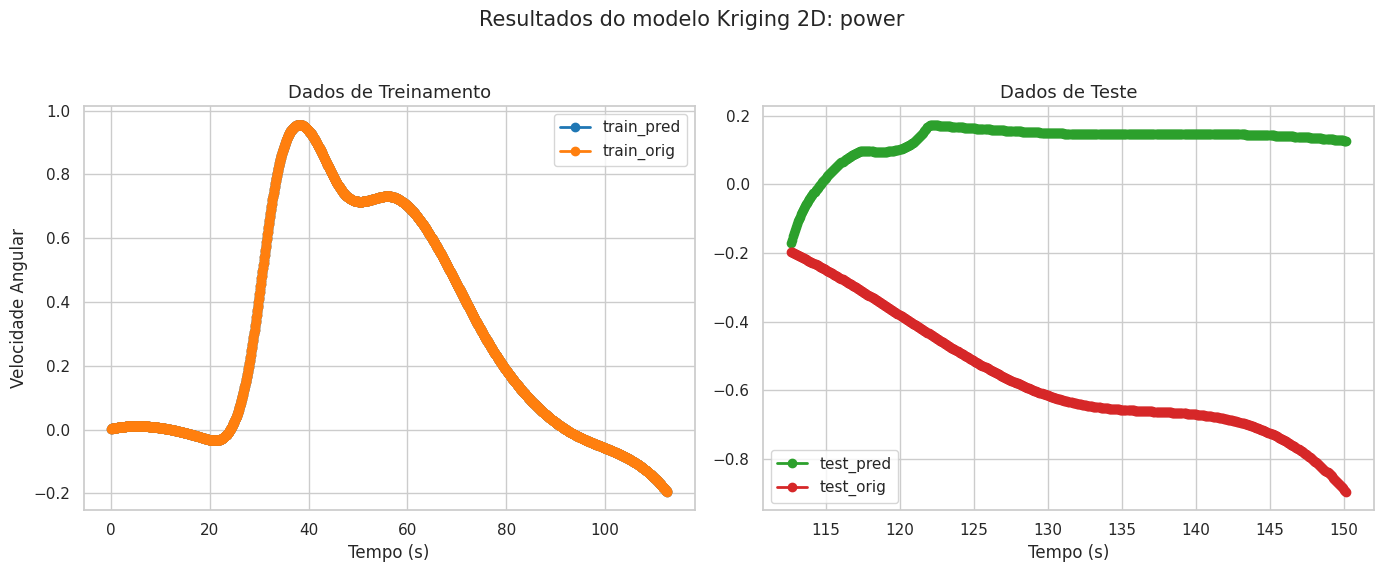

{'r2_training': 1.0,
 'mse_training': 2.1930160382620114e-27,
 'mape_training': 2.6914395104962856e-12,
 'rmse_training': 4.6829649136652855e-14,
 'r2_test': -10.494197566762203,
 'mse_test': 0.34935195047971973,
 'mape_test': 0.9753744900388526,
 'rmse_test': 0.5910600227385707}

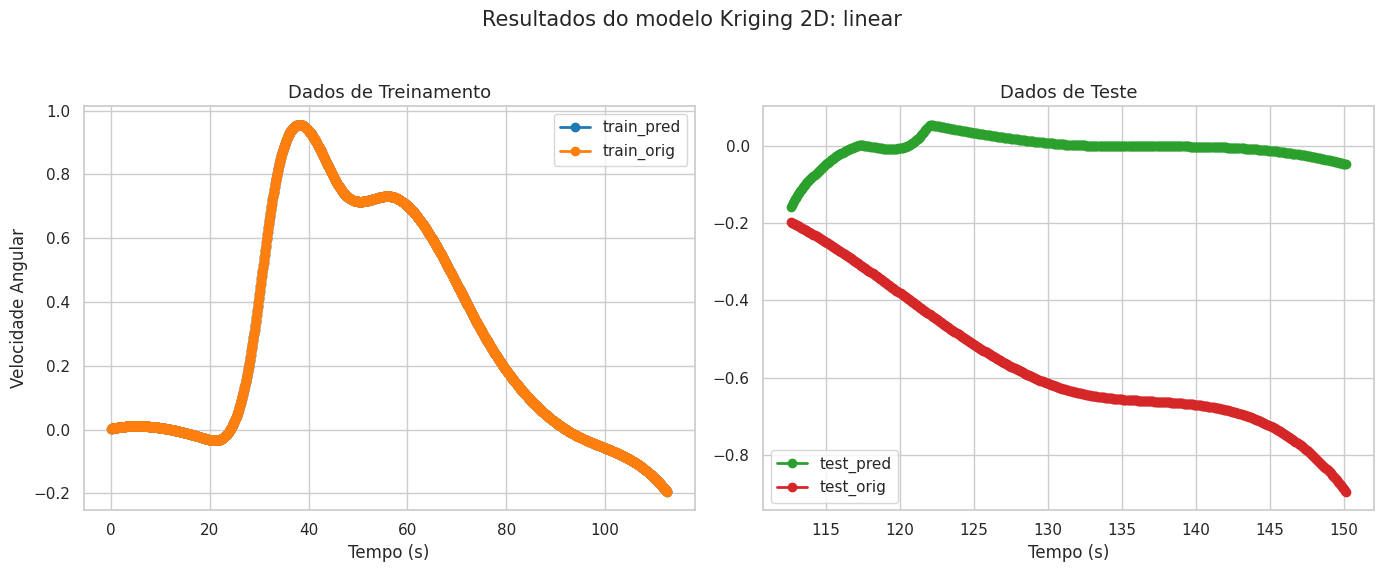

{'r2_training': 1.0,
 'mse_training': 1.9974956778700374e-25,
 'mape_training': 2.166088073401282e-11,
 'rmse_training': 4.469335160703477e-13,
 'r2_test': -17.984755434019633,
 'mse_test': 0.5770182130359435,
 'mape_test': 1.274692346196506,
 'rmse_test': 0.7596171489875301}

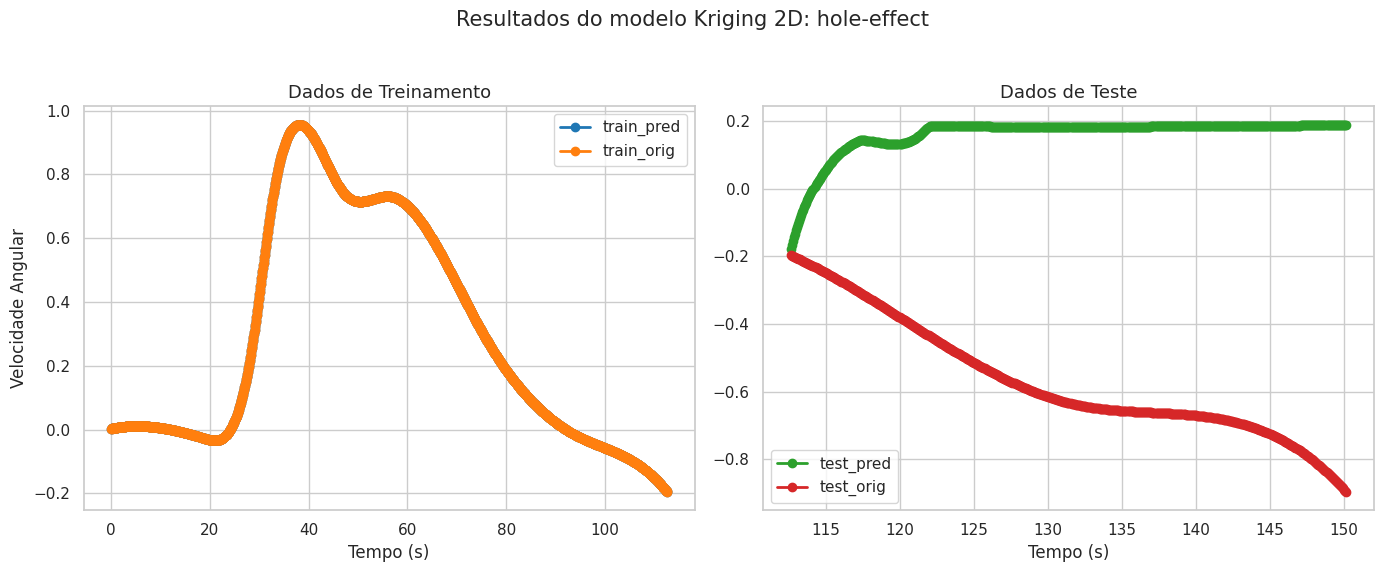

In [39]:
Vsg = Kriging3D(Dataset=data)        
Vsg.EvalModel("./content/KrigingMetrics.xlsx")